<a href="https://colab.research.google.com/github/deartoms/python/blob/main/Visualization%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') # matplotlib 기본 폰트로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family']) # 현재 적용된 폰트 이름 출력

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트:  ['NanumGothic']


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 타이타닉 데이터 로드
titanic = pd.read_csv('/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/train.csv')
print(titanic.shape)
titanic.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
titanic_clean = titanic.copy()

# Cabin 열 삭제
titanic_clean = titanic_clean.drop(columns=['Cabin'])

# Age 결측치 처리
titanic_clean['Age'] = titanic_clean.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked 결측치 처리
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(
    titanic_clean['Embarked'].mode()[0]
)

# 최종 결측치 현황 확인
print("전처리 후 결측치: ")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f"\n 원본 shape: {titanic.shape}")
print(f"전처리 후 shape: {titanic_clean.shape}")

전처리 후 결측치: 
Series([], dtype: int64)

 원본 shape: (891, 12)
전처리 후 shape: (891, 11)


### 1. matplotlib으로 그래프 그리기

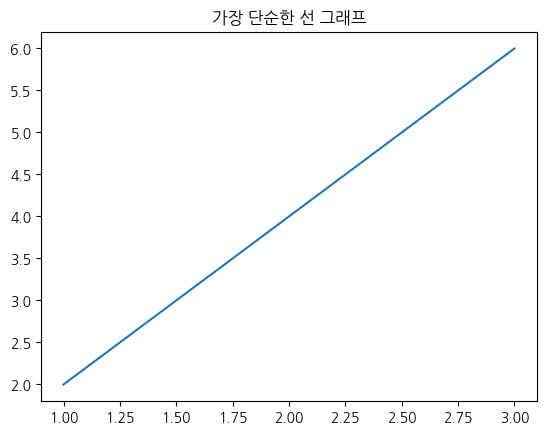

In [30]:
# plt.plot(x좌표 리스트, y좌표 리스트) 선 그래프
plt.plot([1, 2, 3], [2, 4, 6])
plt.title('가장 단순한 선 그래프')
plt.show()

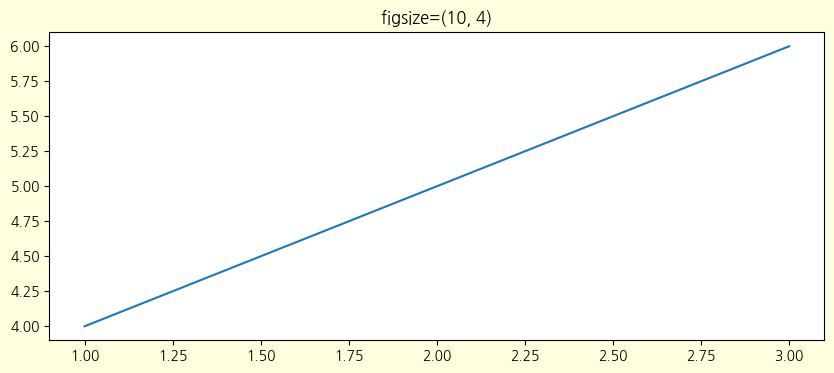

In [31]:
# Figure: 전체 도화지 (크기, 배경색 설정)
# Axes: 실제 그래프가 그려지는 영역 (축, 제목, 그래프)

plt.figure(figsize=(10, 4), facecolor='lightyellow') # 가로 10, 세로 4인치, 배경색 설정
plt.plot([1, 2, 3], [4, 5, 6])
plt.title('figsize=(10, 4)')
plt.show()

In [32]:
# Axes 객체 생성
ax = plt.axes()
print('ax 타입:', type(ax))
plt.close()

ax 타입: <class 'matplotlib.axes._axes.Axes'>


In [33]:
# Figure + Axes 동시 생성
fig, ax = plt.subplots()
print('fig 타입:', type(fig))
print('ax 타입:', type(ax))
plt.close()

fig 타입: <class 'matplotlib.figure.Figure'>
ax 타입: <class 'matplotlib.axes._axes.Axes'>


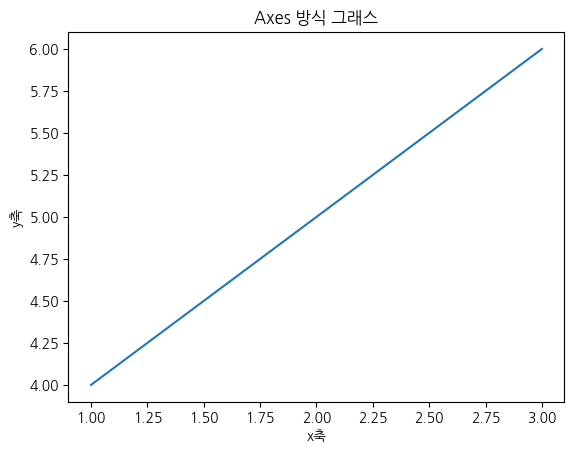

In [34]:
# Axes 객체 방식으로 그래프 그리기
# plt.plot() -> ax.plot()
# plt.title() -> ax.set_title()
fig, ax = plt.subplots()

ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title('Axes 방식 그래스')
ax.set_xlabel('x축')
ax.set_ylabel('y축')
plt.show()

# [plt 방식 vs Axes 방식 비교]
# plt.plot() <-> ax.plot()
# plt.xlabel() <-> ax.set_xlabel()
# plt.ylabel() <-> ax.set_ylabel()
# plt.title() <-> ax.set_title()
# plt.legend() <-> ax.legend()

In [35]:
# 여러 개의 subplot 생성
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))

print('ax 타입:', type(ax))
print('ax[0]타입:', type(ax[0]))
print('ax[1]타입:', type(ax[1]))
plt.close()

ax 타입: <class 'numpy.ndarray'>
ax[0]타입: <class 'matplotlib.axes._axes.Axes'>
ax[1]타입: <class 'matplotlib.axes._axes.Axes'>


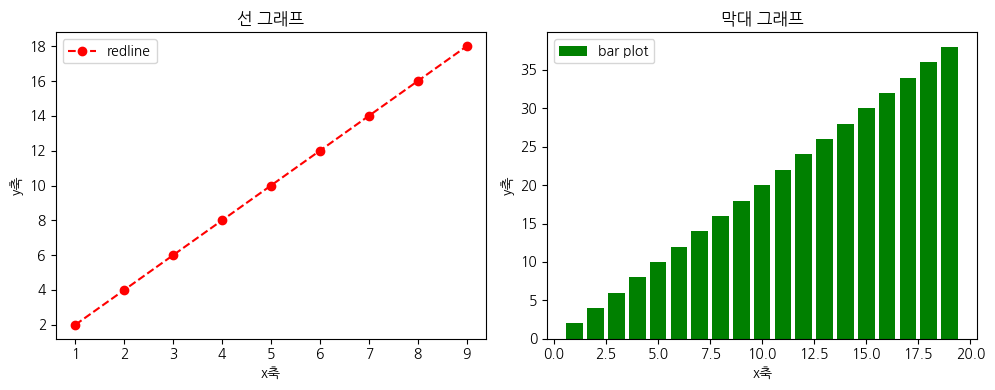

In [36]:
# 1x2 subplot
x1 = np.arange(1, 10)
x2 = np.arange(1, 20)
y1 = 2 * x1
y2 = 2 * x2

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(x1, y1, color='red', marker='o', linestyle='dashed', label='redline')
ax[0].set_xlabel('x축')
ax[0].set_ylabel('y축')
ax[0].legend()
ax[0].set_title('선 그래프')

ax[1].bar(x2, y2, color='green', label='bar plot')
ax[1].set_xlabel('x축')
ax[1].set_ylabel('y축')
ax[1].legend()
ax[1].set_title('막대 그래프')

plt.tight_layout() # 여러 subplot 간격 자동 조정
plt.show()

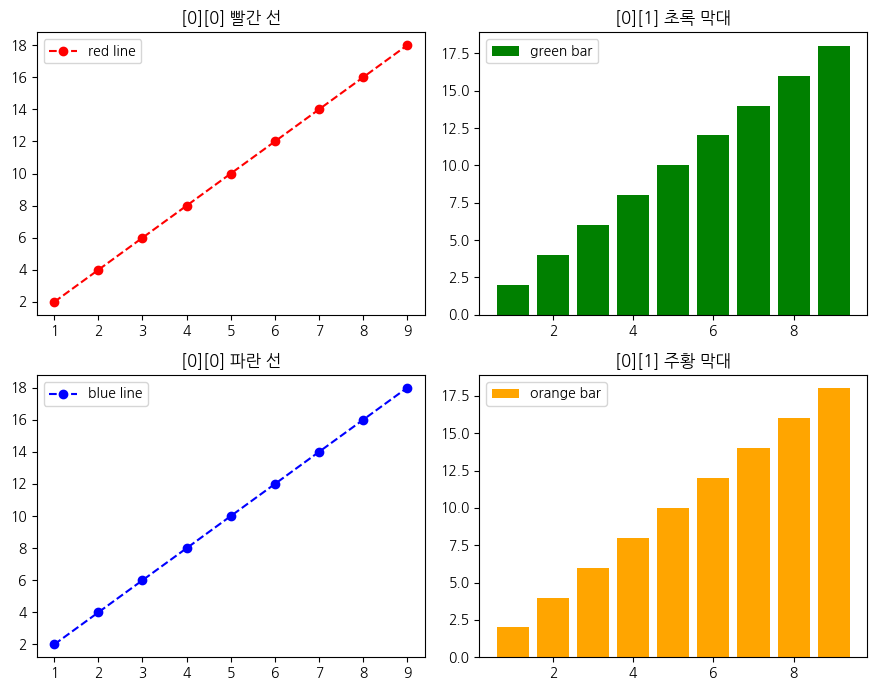

In [37]:
# 2x2 subplot: 2D 이차원 배열로 변환, ax[행][열]로 접근
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(9, 7))

x1 = np.arange(1, 10)
x2 = np.arange(1, 20)
y1 = 2 * x1
y2 = 2 * x2

# ax[0][0]: 1행 1열 (왼쪽 상단)
ax[0][0].plot(x1, y1, color='red', marker='o', linestyle='dashed', label='red line')
ax[0][0].set_title('[0][0] 빨간 선')
ax[0][0].legend()

# ax[0][1]: 1행 2열 (오른쪽 상단)
ax[0][1].bar(x1, y1, color='green', label='green bar')
ax[0][1].set_title('[0][1] 초록 막대')
ax[0][1].legend()

# ax[1][0]: 2행 1열 (왼쪽 하단)
ax[1][0].plot(x1, y1, color='blue', marker='o', linestyle='dashed', label='blue line')
ax[1][0].set_title('[0][0] 파란 선')
ax[1][0].legend()

# ax[1][1]: 2행 2열 (오른쪽 하단)
ax[1][1].bar(x1, y1, color='orange', label='orange bar')
ax[1][1].set_title('[0][1] 주황 막대')
ax[1][1].legend()

plt.tight_layout()
plt.show()

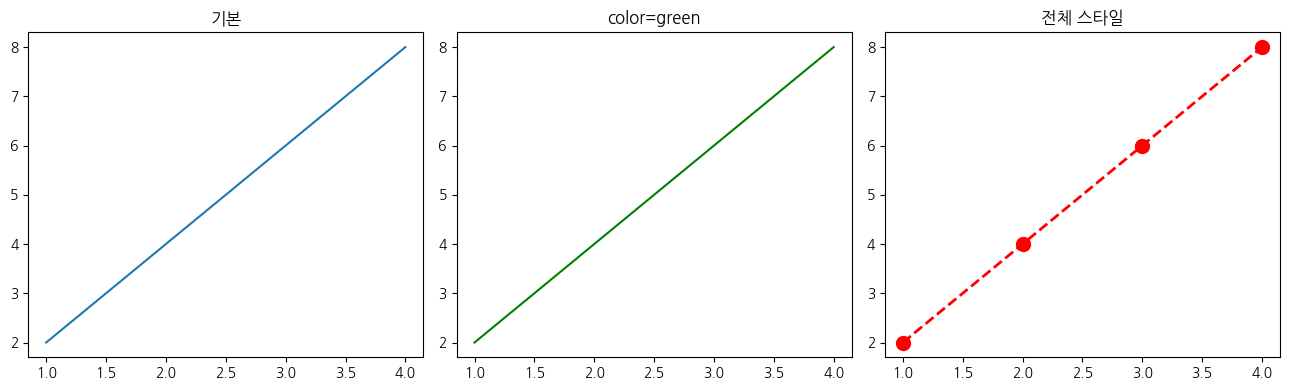

In [38]:
# 선 그래프 옵션 - 색상, 마커, 축, 범례

x_val = [1, 2, 3, 4]
y_val = [2, 4, 6, 8]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(x_val, y_val)
axes[0].set_title('기본')

axes[1].plot(x_val, y_val, color='green')
axes[1].set_title('color=green')

axes[2].plot(x_val, y_val,
             color='red',
             marker='o',
             linestyle='dashed',
             linewidth=2,
             markersize=10)
axes[2].set_title('전체 스타일')

plt.tight_layout()
plt.show()

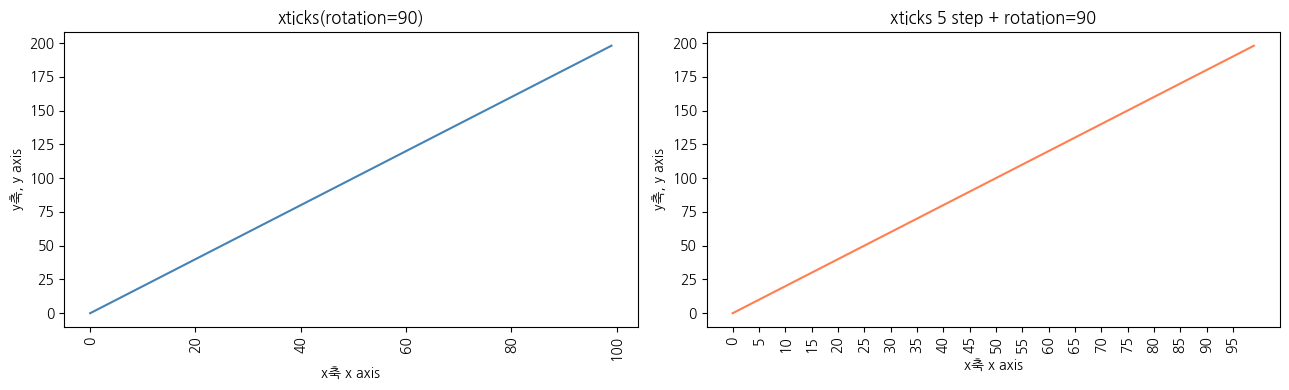

In [39]:
# x축 틱(눈금) 회전
x_value = np.arange(0, 100)
y_value = 2 * x_value

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_value, y_value, color='steelblue')
axes[0].set_xlabel('x축 x axis')
axes[0].set_ylabel('y축, y axis')
axes[0].set_title('xticks(rotation=90)')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(x_value, y_value, color='coral')
axes[1].set_xlabel('x축 x axis')
axes[1].set_ylabel('y축, y axis')
axes[1].set_title('xticks 5 step + rotation=90')
axes[1].set_xticks(np.arange(0, 100, 5)) # 0부터 99까지 5 간격으로 표시하고 90도 회전
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# plt 방식: plt.xtickets(rotation=90)
# axes 방식; ax.tick_params(axis=x, rotation=90)

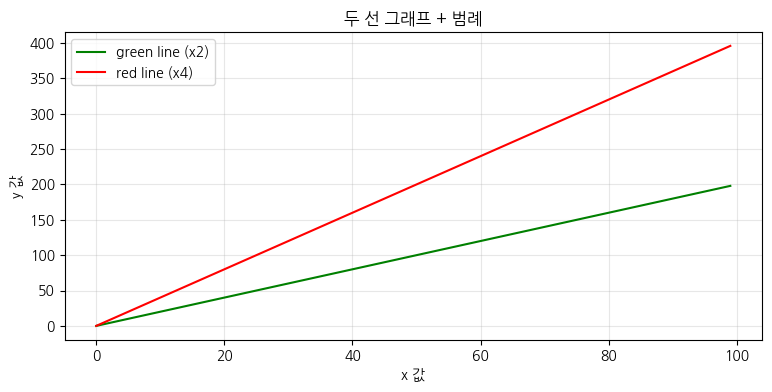

In [40]:
# 범례(legend) 설정
x_value = np.arange(0, 100)
y1 = 2 * x_value
y2 = 4 * x_value

plt.figure(figsize=(9, 4))

plt.plot(x_value, y1, color='green', label='green line (x2)')
plt.plot(x_value, y2, color='red', label='red line (x4)')

plt.xlabel('x 값')
plt.ylabel('y 값')
plt.title('두 선 그래프 + 범례')

# legend(): label이 설정된 그래프들을 자동으로 범례에 추가
# loc 인자로 위치 조정: 'upper right'(기본), 'upper left', 'lower right'등
plt.legend(loc='upper left')

plt.grid(True, alpha=0.3) # 격자 추가
plt.show()

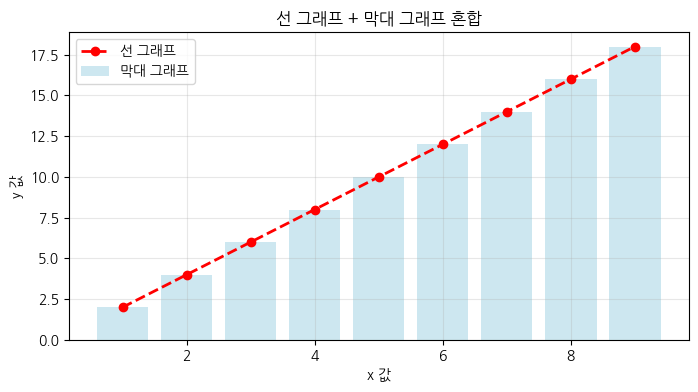

In [41]:
# 선 그래프 + 막대 그래프 같은 Axes에 그리기
x = np.arange(1, 10)
y = 2 * x

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, color='red', marker='o', linestyle='dashed', label='선 그래프', linewidth=2)
ax.bar(x, y, color='lightblue', alpha=0.6, label='막대 그래프')

ax.set_xlabel('x 값')
ax.set_ylabel('y 값')
ax.set_title('선 그래프 + 막대 그래프 혼합')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 2. seaborn으로 그래프 그리기

In [42]:
# 타이타닉 데이터 확인
print(titanic_clean.shape)
print(titanic_clean.columns.tolist())
display(titanic_clean.tail())

(891, 11)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q


* 이산형: 셀 수 있는(countable)값(정수 형태),
* 연속형: 측정 가능한 범위 내에서 어떤 값이든 가질 수 있는(실수 형태)

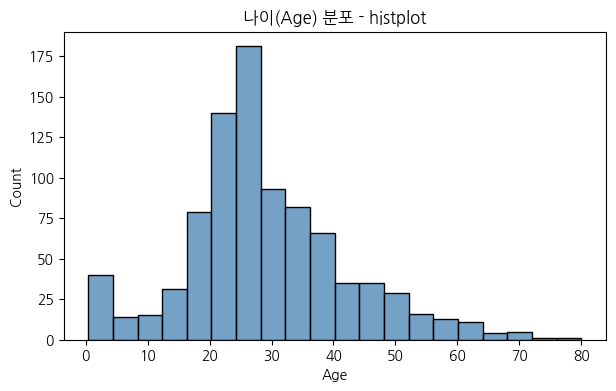

In [45]:
# 히스토그램 (Histogram)
# 연속형 데이터의 구간별 도수 분포 - 데이터가 어떻게 퍼져 있는지 확인
plt.figure(figsize=(7, 4))

sns.histplot(titanic_clean['Age'], bins=20, color='steelblue')
plt.title('나이(Age) 분포 - histplot')
plt.show()

# sns.histplot()의 첫 번째 인자: Series 또는 (x=컬럼명, data=df)
# bins = 막대 개수 (많을수록 세밀)
# DataFrame 컬럼명을 자동으로 인식해 xlabel 설정

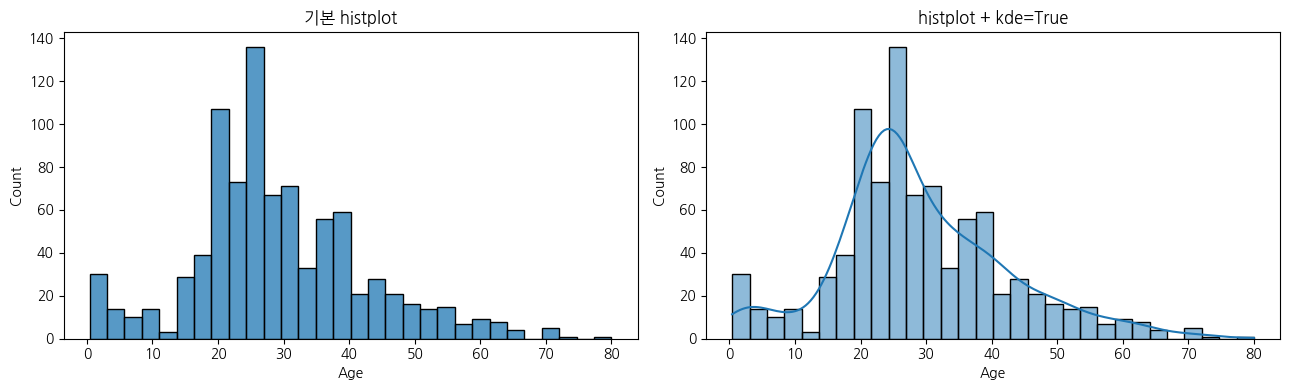

In [46]:
# kde=True: 커널 밀도 추정 곡선 추가
# kde: Kernel Density Estimation - 부드러운 분포 곡선
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(x='Age', data=titanic_clean, bins=30, ax=axes[0])
axes[0].set_title('기본 histplot')

sns.histplot(x='Age', data=titanic_clean, bins=30, kde=True, ax=axes[1])
axes[1].set_title('histplot + kde=True')

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

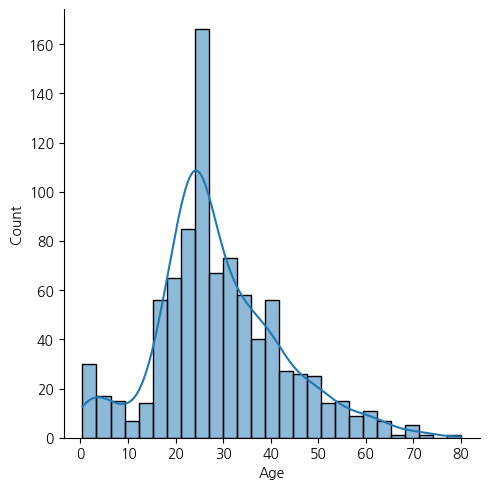

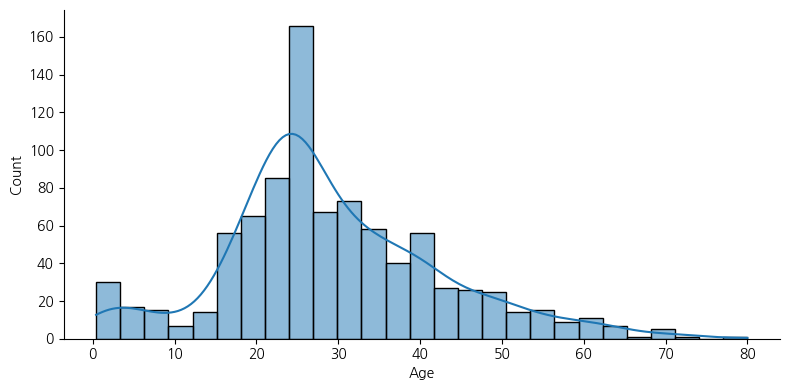

In [49]:
# 올바른 크기 설정 방법: height, aspect 파라미터
plt.figure(figsize=(8, 4)) # <- 이 설정은 displot에 무시됨, 기본 크기로 출력
sns.displot(x='Age', data=titanic_clean, kde=True)
plt.show()

sns.displot(titanic_clean['Age'], kde=True, height=4, aspect=2) # 가로=heightXaspect
plt.show()

# histplot(Axes 레벨): plt.figure() 적용 -> ax= 배치 가능
# displot(Figure 레벨): plt.figure() 무시 -> height, aspect 사용

/tmp/ipykernel_221/2797846692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=titanic_clean, ax=axes[0], palette='Set2') # palette: 색상 팔레트
/tmp/ipykernel_221/2797846692.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=titanic_clean, ax=axes[1], palette=['#FF5722', '#4CAF50'])
/tmp/ipykernel_221/2797846692.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['사망(0)', '생존(1)'])
/tmp/ipykernel_221/2797846692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

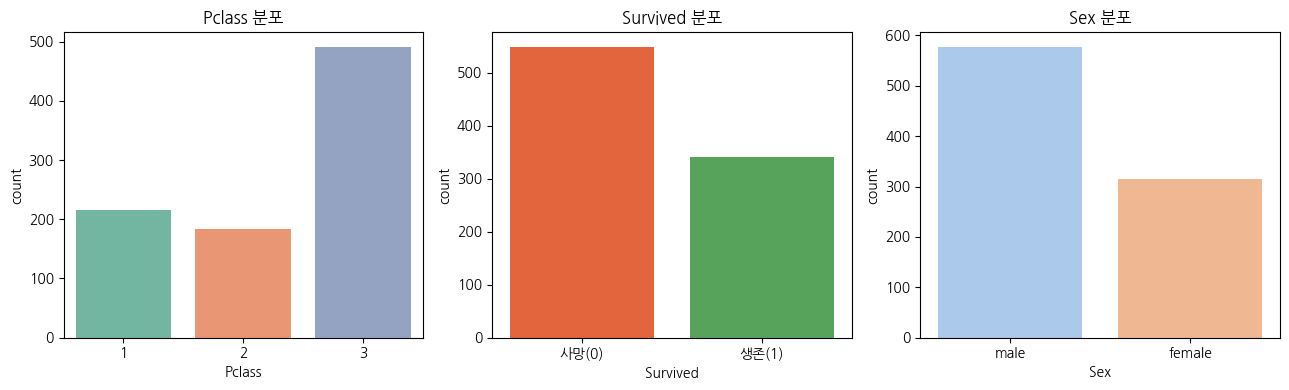

In [51]:
# 카운트 플롯 (Count Plot)
# 범주형 변수의 값별 건수 시각화 - x축: 카테고리, y축: 자동 계산된 건수
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# countplot: x축에 범주형 컬럼을 지정하면 y축(건수)을 자동 계산
# Pclass별 승객 수
sns.countplot(x='Pclass', data=titanic_clean, ax=axes[0], palette='Set2') # palette: 색상 팔레트
axes[0].set_title('Pclass 분포')

# 생존 여부별 건수
sns.countplot(x='Survived', data=titanic_clean, ax=axes[1], palette=['#FF5722', '#4CAF50'])
axes[1].set_title('Survived 분포')
axes[1].set_xticklabels(['사망(0)', '생존(1)'])

# 성별 건수
sns.countplot(x='Sex', data=titanic_clean, ax=axes[2], palette='pastel')
axes[2].set_title('Sex 분포')

plt.tight_layout()
plt.show()

/tmp/ipykernel_221/3844877188.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=titanic_clean,
/tmp/ipykernel_221/3844877188.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=titanic_clean,


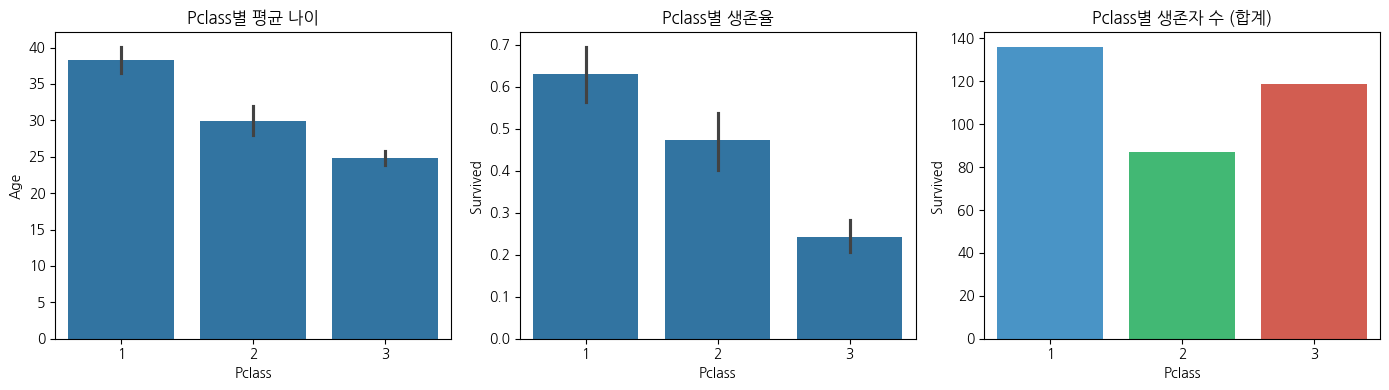

In [54]:
# 바 플롯 (Bar Plot)
# x축: 범주형, y축: 연속형의 집계(기본=평균)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Pclass별 평균 나이
sns.barplot(x='Pclass', y='Age', data=titanic_clean, ax=axes[0])
axes[0].set_title('Pclass별 평균 나이')

# Pclass별 생존율 (Survived의 평균= 생존율)
sns.barplot(x='Pclass', y='Survived', data=titanic_clean, ax=axes[1])
axes[1].set_title('Pclass별 생존율')

# ci=None: 신뢰구간 제거
sns.barplot(x='Pclass', y='Survived', data=titanic_clean,
            ci=None, estimator=sum,
            palette=['#3498DB', '#2ECC71', '#E74C3C'], ax=axes[2])
axes[2].set_title('Pclass별 생존자 수 (합계)')

plt.tight_layout()
plt.show()

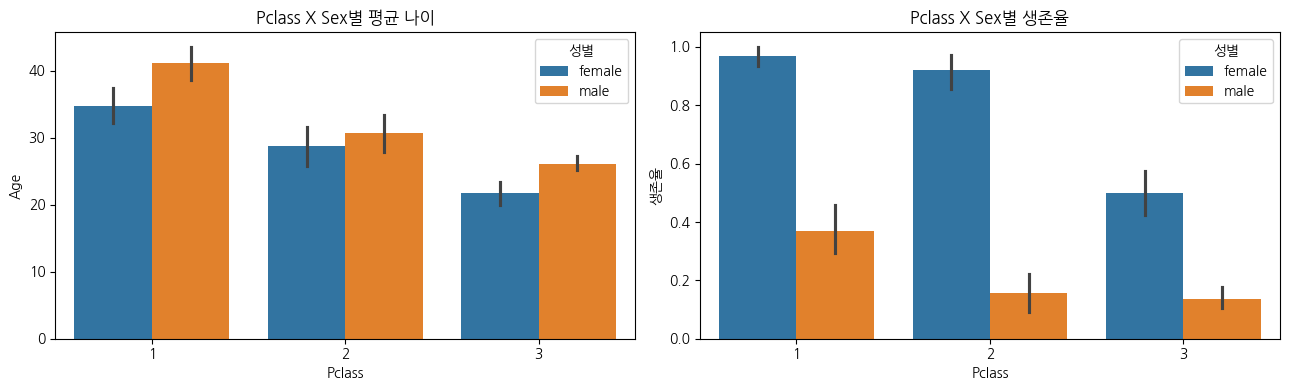

In [55]:
# hue 인자: 추가 범주로 세분화
# hue= 'Sex' : 각 Pclass 안에서 Male/Female을 색상으로 구분

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pclass X Sex별 평균 나이
sns.barplot(x='Pclass', y='Age', hue='Sex', data=titanic_clean, ax=axes[0])
axes[0].set_title('Pclass X Sex별 평균 나이')
axes[0].legend(title='성별')

# Pclass X Sex별 생존율
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_clean, ax=axes[1])
axes[1].set_title('Pclass X Sex별 생존율')
axes[1].legend(title='성별')
axes[1].set_ylabel('생존율')

plt.tight_layout()
plt.show()

/tmp/ipykernel_221/3302711844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=titanic_clean, ax=axes[1], palette='Set3')


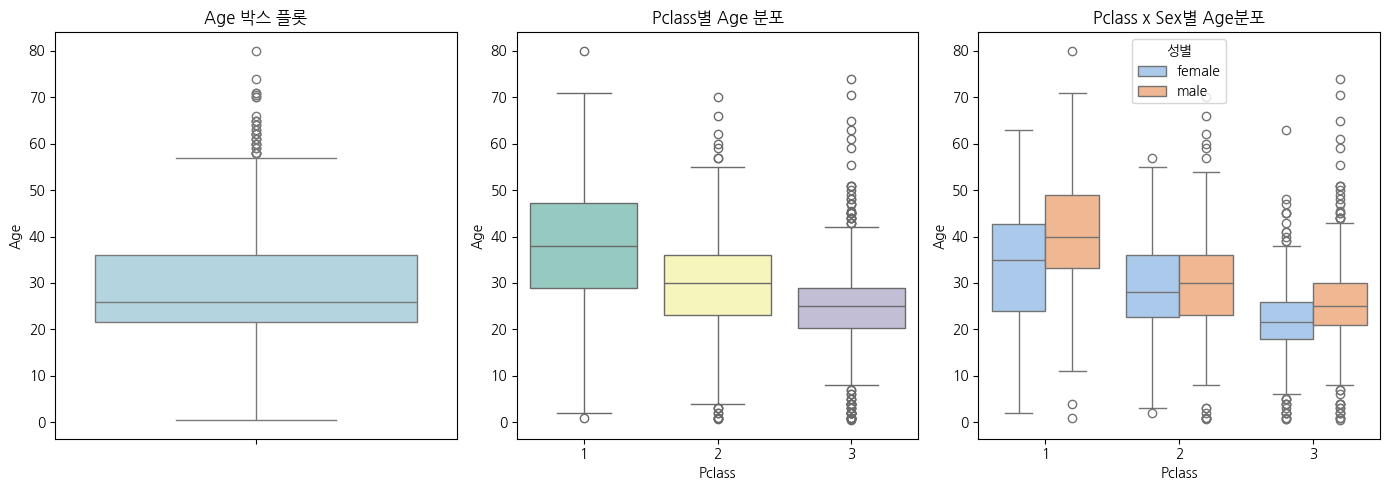

In [56]:
# 박스 플롯 (Box Plot)
# 데이터의 4분위수를 박스로 표현 - 중앙값, 분포, 이상치 한눈에 파악
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 단일 컬럼 박스 플롯
sns.boxplot(y='Age', data=titanic_clean, ax=axes[0], color='lightblue')
axes[0].set_title('Age 박스 플롯')

# Pclass별 Age 박스 플롯
# x축: 범주형 / y축: 연속형 -> 범주별 분포 비교 가능
sns.boxplot(x='Pclass', y='Age', data=titanic_clean, ax=axes[1], palette='Set3')
axes[1].set_title('Pclass별 Age 분포')

# hue='Sex': Pclass X Sex별 박스 플롯 (6개 박스)
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_clean, ax=axes[2], palette='pastel')
axes[2].set_title('Pclass x Sex별 Age분포')
axes[2].legend(title='성별')

plt.tight_layout()
plt.show()

/tmp/ipykernel_221/3021371471.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Pclass', y='Age', data=titanic_clean, ax=axes[1], palette='muted')


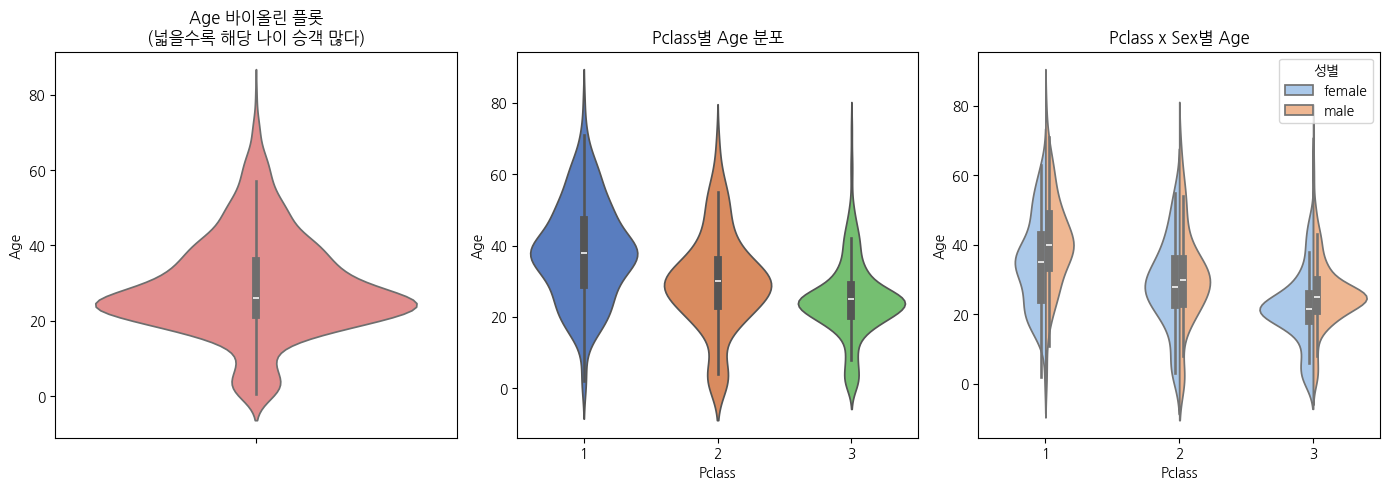

In [58]:
# 바이올린 플롯 (Violin Plot)
# 박스 플롯 + 확률 밀도 곡선 - 데이터 분포 형태를 더 자세히 파악
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 단일 컬럼 바이올린 플롯
sns.violinplot(y='Age', data=titanic_clean, ax=axes[0], color='lightcoral')
axes[0].set_title('Age 바이올린 플롯\n(넓을수록 해당 나이 승객 많다)')

# Pclass별 Age 바이올린 플롯
sns.violinplot(x='Pclass', y='Age', data=titanic_clean, ax=axes[1], palette='muted')
axes[1].set_title('Pclass별 Age 분포')

# hue='Sex': split=True로 좌우를 성별로 분할
sns.violinplot(x='Pclass', y='Age', hue='Sex', data=titanic_clean, ax=axes[2], split=True, palette='pastel')
axes[2].set_title('Pclass x Sex별 Age')
axes[2].legend(title='성별')

plt.tight_layout()
plt.show()

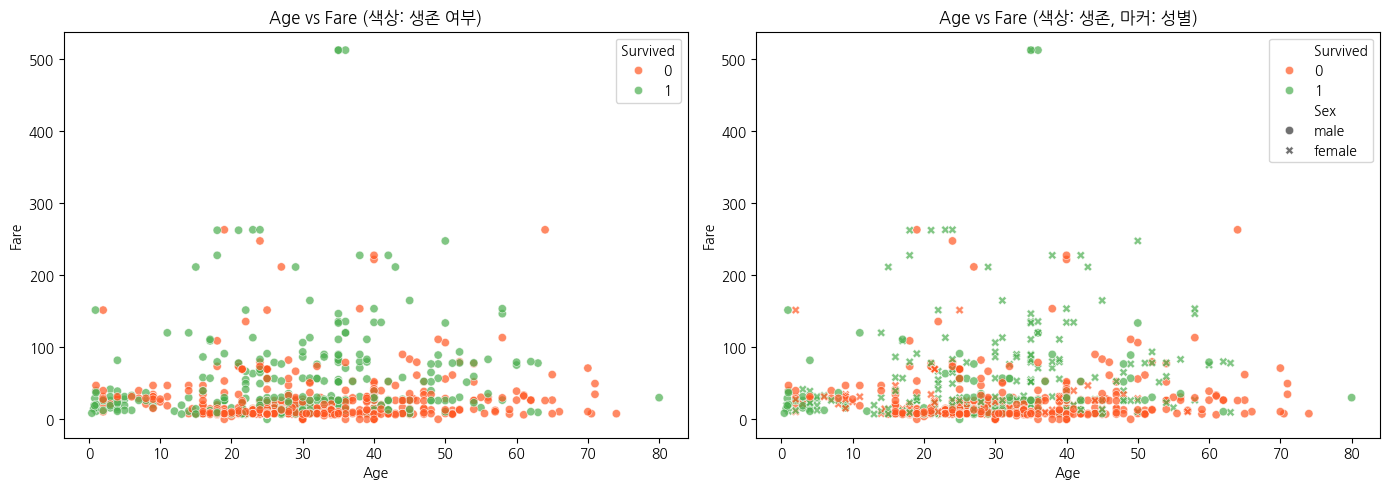

In [60]:
# 산점도 (Scatter Plot)
# X와 Y 두 연속형 변수 간의 관계 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5) )

# hue: 범주형 컬럼으로 색상 구분
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=titanic_clean, ax=axes[0],
                palette=['#FF5722', '#4CAF50'], alpha=0.7)
axes[0].set_title('Age vs Fare (색상: 생존 여부)')

# hue + style: 색상과 마커 모양 모두 구분
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Sex', data=titanic_clean, ax=axes[1],
                palette=['#FF5722', '#4CAF50'], alpha=0.7)
axes[1].set_title('Age vs Fare (색상: 생존, 마커: 성별)')

plt.tight_layout()
plt.show()

In [61]:
# 상관 히트맵 (Correlation Heatmap)
# 컬럼 간 피어슨(Pearson) 상관계수(-1 -1)를 색상 강도로 표현

corr = titanic_clean.select_dtypes(include=np.number).corr() # '숫자'로 분류될 수 있는 모든 컬럼들만 필터링하여 새로운 Data
print('상관계수 행렬 (일부):')
print(corr.round(2))

상관계수 행렬 (일부):
             PassengerId  Survived  Pclass   Age  SibSp  Parch  Fare
PassengerId         1.00     -0.01   -0.04  0.04  -0.06  -0.00  0.01
Survived           -0.01      1.00   -0.34 -0.06  -0.04   0.08  0.26
Pclass             -0.04     -0.34    1.00 -0.41   0.08   0.02 -0.55
Age                 0.04     -0.06   -0.41  1.00  -0.25  -0.18  0.12
SibSp              -0.06     -0.04    0.08 -0.25   1.00   0.41  0.16
Parch              -0.00      0.08    0.02 -0.18   0.41   1.00  0.22
Fare                0.01      0.26   -0.55  0.12   0.16   0.22  1.00


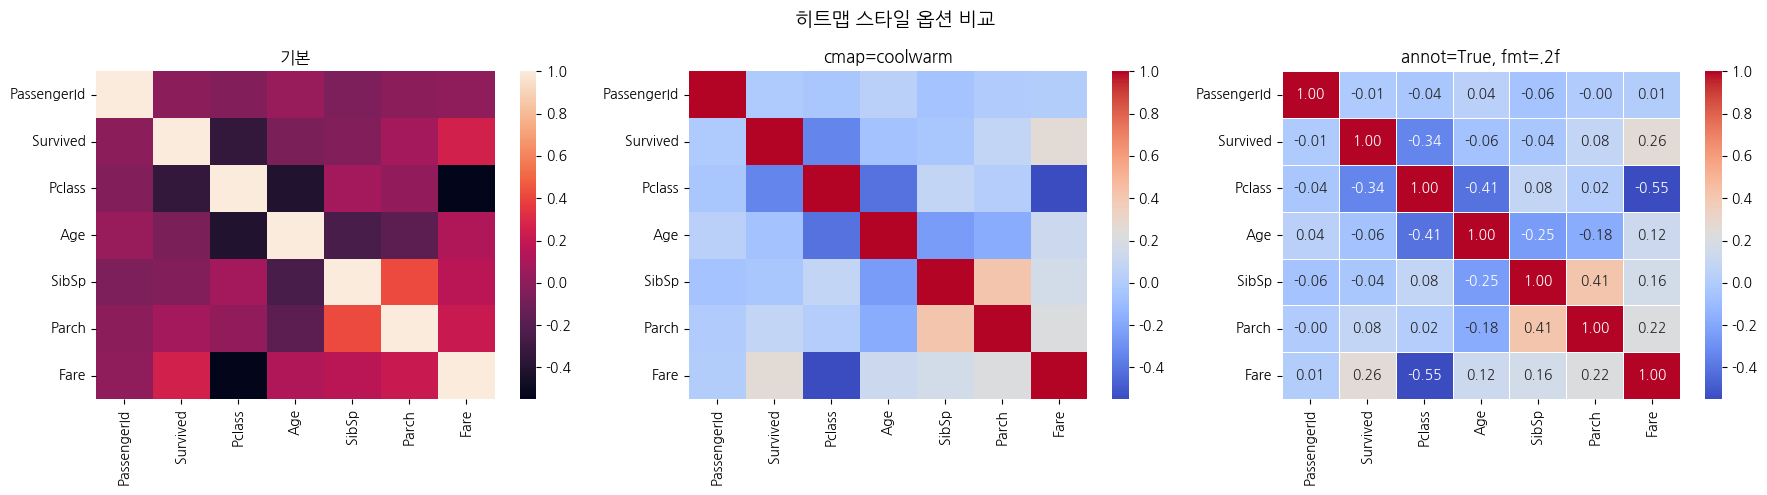

In [63]:
# 히트맵 스타일 옵션 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('히트맵 스타일 옵션 비교', fontsize=14, fontweight='bold')

# 1. 기본 (default 색상맵)
sns.heatmap(corr, ax=axes[0])
axes[0].set_title('기본')

# 2. cmap 변경:'rocket', 'Blues', 'coolwarm', 'RdYlGn' 등
sns.heatmap(corr, cmap='coolwarm', ax=axes[1])
axes[1].set_title('cmap=coolwarm')

# 3. annot=True: 각 셀에 수치 표시, cbar=True: 색상 범례 바 표시
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', cbar=True, linewidths=.5, ax=axes[2])
axes[2].set_title('annot=True, fmt=.2f')

plt.tight_layout()
plt.show()

/tmp/ipykernel_221/3054150962.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=titanic_clean, ax=ax1, palette=['#FF5722', '#4CAF50'])
/tmp/ipykernel_221/3054150962.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['사망(0)', '생존(1)'])
/tmp/ipykernel_221/3054150962.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=titanic_clean, ax=ax2, palette='Set2')
/tmp/ipykernel_221/3054150962.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fal

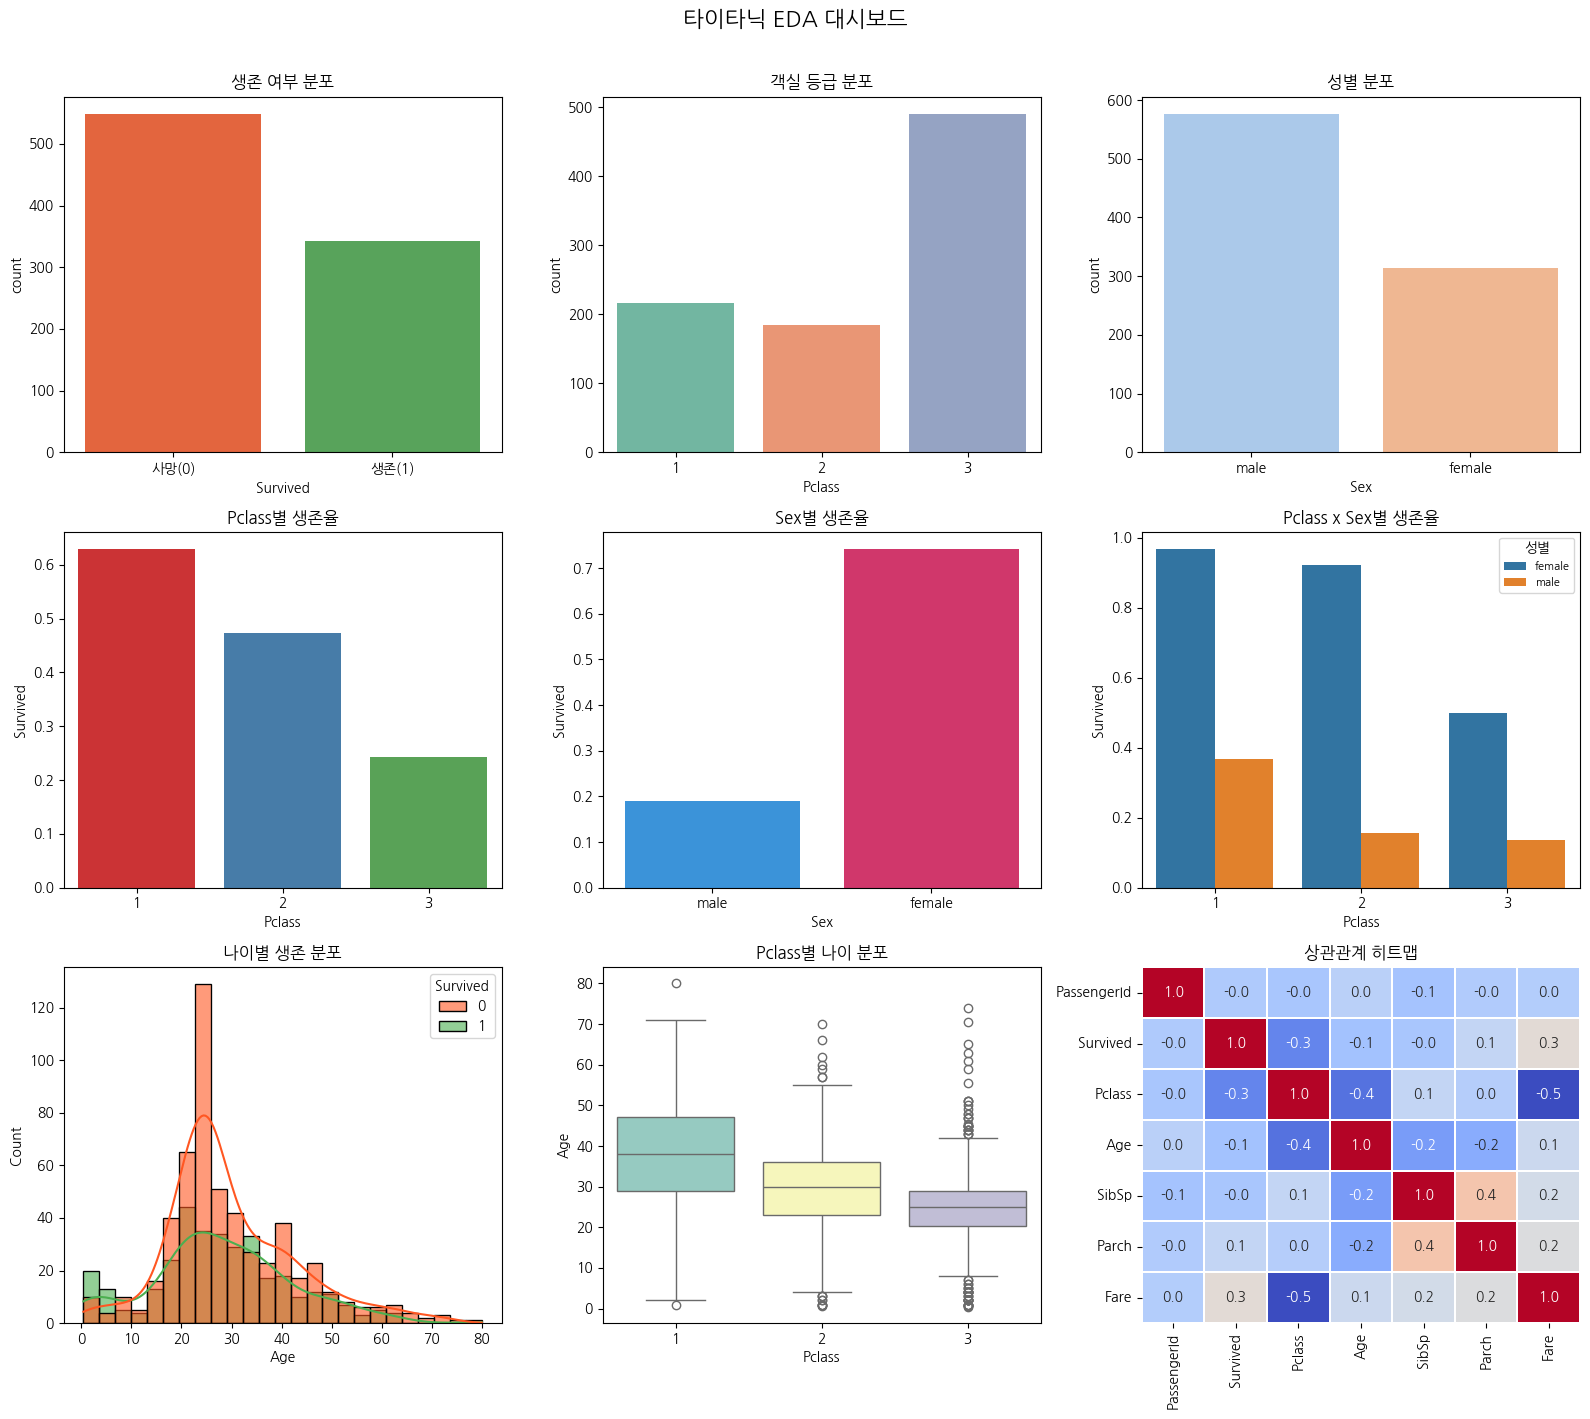

In [67]:
# 타이타닉 EDA 대시보드
fig = plt.figure(figsize=(16, 14))
fig.suptitle('타이타닉 EDA 대시보드', fontsize=16, fontweight='bold', y=1.01)

# 1행: 범주형 분포
ax1 = fig.add_subplot(3, 3, 1)
sns.countplot(x='Survived',data=titanic_clean, ax=ax1, palette=['#FF5722', '#4CAF50'])
ax1.set_title('생존 여부 분포')
ax1.set_xticklabels(['사망(0)', '생존(1)'])

ax2 = fig.add_subplot(3, 3, 2)
sns.countplot(x='Pclass', data=titanic_clean, ax=ax2, palette='Set2')
ax2.set_title('객실 등급 분포')

ax3 = fig.add_subplot(3, 3, 3)
sns.countplot(x='Sex', data=titanic_clean, ax=ax3, palette='pastel')
ax3.set_title('성별 분포')

# 2행: 생존율 분석
ax4 = fig.add_subplot(3, 3, 4)
sns.barplot(x='Pclass', y='Survived', data=titanic_clean, ax=ax4, palette='Set1', ci=None)
ax4.set_title('Pclass별 생존율')

ax5 = fig.add_subplot(3, 3, 5)
sns.barplot(x='Sex', y='Survived', data=titanic_clean, ax=ax5, palette=['#2196F3','#E91E63'], ci=None)
ax5.set_title('Sex별 생존율')

ax6 = fig.add_subplot(3, 3, 6)
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_clean, ax=ax6, ci=None)
ax6.set_title('Pclass x Sex별 생존율')
ax6.legend(title='성별', fontsize=8)

# 3행: 연속형 분포
ax7 = fig.add_subplot(3, 3, 7)
sns.histplot(x='Age', data=titanic_clean, hue='Survived', bins=25, kde=True, ax=ax7,
             palette=['#FF5722', '#4CAF50'], alpha=0.6)
ax7.set_title('나이별 생존 분포')

ax8 = fig.add_subplot(3, 3, 8)
sns.boxplot(x='Pclass', y='Age', data=titanic_clean, ax=ax8, palette='Set3')
ax8.set_title('Pclass별 나이 분포')

ax9 = fig.add_subplot(3, 3, 9)
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', ax=ax9, cbar=False, linewidths=0.3)
ax9.set_title('상관관계 히트맵')

plt.tight_layout()
plt.show()

### 3. pandas로 그래프 그리기

### 4. 상관관계 분석 그래프